In [1]:
from datetime import datetime
from itertools import product
from pathlib import Path
import json
import random

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.svm import SVC


def find_project_root(start_path: Path) -> Path:
    for candidate in (start_path.resolve(), *start_path.resolve().parents):
        has_repo_markers = (candidate / ".github").exists() or (candidate / ".git").exists()
        if has_repo_markers and (candidate / "datasets").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate the repository root from notebook working directory: {start_path}"
    )


RANDOM_SEED = 42
PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "datasets" / "postprocessed-CHEMBL379_IC50" / "scaled_dataset"
TARGET_COLUMN = "activity"
METADATA_COLUMNS = [
    "representative_molecule_chembl_id",
    "smiles",
    "canonical_smiles",
    "activity",
    "threshold_nm",
    "source_record_count",
    "source_molecule_chembl_ids",
    "source_relations",
    "source_values_nm",
    "label_sources",
    "target_chembl_id",
]
CLASS_LABELS = ("Inactive (0)", "Active (1)")

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Expected scaled dataset directory was not found: {DATA_DIR}")

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Scaled dataset directory: {DATA_DIR}")
print(f"Random seed: {RANDOM_SEED}")

Project root: C:\Users\CaVi962\vscodeprojects\Magestic-NN
Scaled dataset directory: C:\Users\CaVi962\vscodeprojects\Magestic-NN\datasets\postprocessed-CHEMBL379_IC50\scaled_dataset
Random seed: 42


In [2]:
RESULTS_ROOT = PROJECT_ROOT / "results" / "classical_ml_baseline"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


def create_next_experiment_run_dir(results_root: Path) -> Path:
    experiment_indices: list[int] = []

    for candidate in results_root.iterdir():
        if not candidate.is_dir() or not candidate.name.startswith("experiment_"):
            continue

        suffix = candidate.name.removeprefix("experiment_")
        if suffix.isdigit():
            experiment_indices.append(int(suffix))

    next_index = max(experiment_indices, default=0) + 1
    return results_root / f"experiment_{next_index:03d}"


existing_run_dir = globals().get("RUN_DIR")
reuse_existing_run_dir = False

if isinstance(existing_run_dir, Path):
    try:
        reuse_existing_run_dir = (
            existing_run_dir.parent == RESULTS_ROOT
            and existing_run_dir.name.startswith("experiment_")
        )
    except OSError:
        reuse_existing_run_dir = False

if reuse_existing_run_dir:
    RUN_DIR = existing_run_dir
else:
    RUN_DIR = create_next_experiment_run_dir(RESULTS_ROOT)

PLOTS_DIR = RUN_DIR / "plots"
for output_dir in (RUN_DIR, PLOTS_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

print(f"Classical-baseline results root: {RESULTS_ROOT}")
print(f"Current run directory: {RUN_DIR}")
if reuse_existing_run_dir:
    print("Reusing existing run directory for this kernel session.")
else:
    print("Allocated a new run directory for this kernel session.")

Classical-baseline results root: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\classical_ml_baseline
Current run directory: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\classical_ml_baseline\experiment_001
Allocated a new run directory for this kernel session.


In [3]:
train_df = pd.read_csv(DATA_DIR / "train_dataset.csv")
validation_df = pd.read_csv(DATA_DIR / "validation_dataset.csv")
test_df = pd.read_csv(DATA_DIR / "test_dataset.csv")

descriptor_columns = [
    column_name
    for column_name in train_df.columns
    if column_name not in METADATA_COLUMNS
]
validation_descriptor_columns = [
    column_name
    for column_name in validation_df.columns
    if column_name not in METADATA_COLUMNS
]
test_descriptor_columns = [
    column_name
    for column_name in test_df.columns
    if column_name not in METADATA_COLUMNS
]

assert TARGET_COLUMN in train_df.columns
assert TARGET_COLUMN in validation_df.columns
assert TARGET_COLUMN in test_df.columns
assert descriptor_columns == validation_descriptor_columns == test_descriptor_columns, (
    "Train, validation, and test splits do not share the same descriptor columns."
)
assert not train_df[descriptor_columns].isnull().any().any()
assert not validation_df[descriptor_columns].isnull().any().any()
assert not test_df[descriptor_columns].isnull().any().any()
assert set(train_df[TARGET_COLUMN].unique()) <= {0, 1}
assert set(validation_df[TARGET_COLUMN].unique()) <= {0, 1}
assert set(test_df[TARGET_COLUMN].unique()) <= {0, 1}

sanity_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(validation_df), len(test_df)],
        "active": [
            int(train_df[TARGET_COLUMN].sum()),
            int(validation_df[TARGET_COLUMN].sum()),
            int(test_df[TARGET_COLUMN].sum()),
        ],
        "inactive": [
            int((train_df[TARGET_COLUMN] == 0).sum()),
            int((validation_df[TARGET_COLUMN] == 0).sum()),
            int((test_df[TARGET_COLUMN] == 0).sum()),
        ],
    }
)

print("Loaded splits successfully.")
print(f"Descriptor column count: {len(descriptor_columns)}")
display(sanity_summary)

Loaded splits successfully.
Descriptor column count: 71


,split,rows,active,inactive
0,train,1686,768,918
1,validation,211,96,115
2,test,211,96,115


In [4]:
X_train = train_df[descriptor_columns].to_numpy(dtype=np.float32)
X_validation = validation_df[descriptor_columns].to_numpy(dtype=np.float32)
X_test = test_df[descriptor_columns].to_numpy(dtype=np.float32)

y_train = train_df[TARGET_COLUMN].to_numpy(dtype=np.int64)
y_validation = validation_df[TARGET_COLUMN].to_numpy(dtype=np.int64)
y_test = test_df[TARGET_COLUMN].to_numpy(dtype=np.int64)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_validation shape: {X_validation.shape}, y_validation shape: {y_validation.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (1686, 71), y_train shape: (1686,)
X_validation shape: (211, 71), y_validation shape: (211,)
X_test shape: (211, 71), y_test shape: (211,)


In [10]:
HYPERPARAMETER_COLUMNS = [
    "C",
    "class_weight",
    "n_estimators",
    "max_depth",
    "min_samples_leaf",
    "kernel",
    "gamma",
]


def generate_logistic_regression_configs() -> list[dict[str, object]]:
    return [
        {"C": c, "class_weight": class_weight}
        for c, class_weight in product([0.1, 1.0, 10.0], [None, "balanced"])
    ]


def generate_random_forest_configs() -> list[dict[str, object]]:
    return [
        {
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "class_weight": class_weight,
        }
        for n_estimators, max_depth, min_samples_leaf, class_weight in product(
            [200, 500],
            [None, 10, 20],
            [1, 3],
            [None, "balanced"],
        )
    ]


def generate_svm_configs() -> list[dict[str, object]]:
    configs: list[dict[str, object]] = []

    for kernel, c_value, class_weight in product(
        ["linear", "rbf"],
        [0.1, 1.0, 10.0],
        [None, "balanced"],
    ):
        if kernel == "linear":
            configs.append(
                {
                    "kernel": kernel,
                    "C": c_value,
                    "class_weight": class_weight,
                }
            )
            continue

        for gamma in ["scale", 0.01, 0.1]:
            configs.append(
                {
                    "kernel": kernel,
                    "C": c_value,
                    "gamma": gamma,
                    "class_weight": class_weight,
                }
            )

    return configs


MODEL_GRIDS = {
    "logistic_regression": generate_logistic_regression_configs(),
    "random_forest": generate_random_forest_configs(),
    "svm": generate_svm_configs(),
}


def build_model(model_family: str, hyperparameters: dict[str, object]):
    if model_family == "logistic_regression":
        return LogisticRegression(
            C=float(hyperparameters["C"]),
            class_weight=hyperparameters.get("class_weight"),
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_SEED,
        )

    if model_family == "random_forest":
        max_depth = hyperparameters.get("max_depth")
        if max_depth is not None:
            max_depth = int(max_depth)

        return RandomForestClassifier(
            n_estimators=int(hyperparameters["n_estimators"]),
            max_depth=max_depth,
            min_samples_leaf=int(hyperparameters["min_samples_leaf"]),
            class_weight=hyperparameters.get("class_weight"),
            n_jobs=-1,
            random_state=RANDOM_SEED,
        )

    if model_family == "svm":
        gamma = hyperparameters.get("gamma", "scale")
        if gamma != "scale":
            gamma = float(gamma)

        return SVC(
            kernel=str(hyperparameters["kernel"]),
            C=float(hyperparameters["C"]),
            gamma=gamma,
            class_weight=hyperparameters.get("class_weight"),
            probability=True,
            random_state=RANDOM_SEED,
        )

    raise ValueError(f"Unsupported model family: {model_family}")


def predict_probabilities(model, features: np.ndarray) -> np.ndarray:
    return model.predict_proba(features)[:, 1]


def compute_binary_classification_metrics(
    targets: np.ndarray,
    probabilities: np.ndarray,
) -> dict[str, float]:
    predictions = (probabilities >= 0.5).astype(np.int64)

    return {
        "accuracy": float(accuracy_score(targets, predictions)),
        "precision": float(precision_score(targets, predictions, zero_division=0)),
        "recall": float(recall_score(targets, predictions, zero_division=0)),
        "f1": float(f1_score(targets, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(targets, probabilities)),
        "log_loss": float(log_loss(targets, probabilities, labels=[0, 1])),
    }


def build_trial_row(
    model_family: str,
    trial_index: int,
    hyperparameters: dict[str, object],
    metrics: dict[str, float],
) -> dict[str, object]:
    row = {column_name: None for column_name in HYPERPARAMETER_COLUMNS}
    row.update(hyperparameters)
    row.update(
        {
            "model_family": model_family,
            "trial_index": trial_index,
            "hyperparameters_json": json.dumps(hyperparameters, sort_keys=True),
            "validation_accuracy": metrics["accuracy"],
            "validation_precision": metrics["precision"],
            "validation_recall": metrics["recall"],
            "validation_f1": metrics["f1"],
            "validation_roc_auc": metrics["roc_auc"],
            "validation_log_loss": metrics["log_loss"],
        }
    )
    return row


def select_best_trial(trials_frame: pd.DataFrame) -> pd.Series:
    sorted_trials = trials_frame.sort_values(
        by=[
            "validation_f1",
            "validation_roc_auc",
            "validation_log_loss",
            "validation_accuracy",
        ],
        ascending=[False, False, True, False],
        kind="stable",
    )
    return sorted_trials.iloc[0]


def extract_hyperparameters(best_trial: pd.Series) -> dict[str, object]:
    return {
        column_name: best_trial[column_name]
        for column_name in HYPERPARAMETER_COLUMNS
        if column_name in best_trial.index and pd.notna(best_trial[column_name])
    }


print("Planned sweep sizes:")
for model_family, configs in MODEL_GRIDS.items():
    print(f"- {model_family}: {len(configs)} configurations")

Planned sweep sizes:
- logistic_regression: 6 configurations
- random_forest: 24 configurations
- svm: 24 configurations


In [8]:
validation_trial_rows: list[dict[str, object]] = []

for model_family, hyperparameter_grid in MODEL_GRIDS.items():
    print(f"Running validation sweep for {model_family} ({len(hyperparameter_grid)} configurations)")

    for trial_index, hyperparameters in enumerate(hyperparameter_grid, start=1):
        model = build_model(model_family, hyperparameters)
        model.fit(X_train, y_train)
        validation_probabilities = predict_probabilities(model, X_validation)
        validation_metrics = compute_binary_classification_metrics(
            y_validation,
            validation_probabilities,
        )
        validation_trial_rows.append(
            build_trial_row(model_family, trial_index, hyperparameters, validation_metrics)
        )

validation_trials_df = pd.DataFrame(validation_trial_rows)

family_winner_rows = []
for model_family in MODEL_GRIDS:
    family_trials = validation_trials_df[validation_trials_df["model_family"] == model_family]
    best_trial = select_best_trial(family_trials)
    family_winner_rows.append(best_trial.to_dict())

family_winners_df = pd.DataFrame(family_winner_rows).sort_values(
    by=["validation_f1", "validation_roc_auc", "validation_log_loss"],
    ascending=[False, False, True],
    kind="stable",
).reset_index(drop=True)

selected_baseline_trial = family_winners_df.iloc[0]
selected_baseline_family = str(selected_baseline_trial["model_family"])
selected_hyperparameters = extract_hyperparameters(selected_baseline_trial)

print("Top validation trials across all families:")
display(
    validation_trials_df.sort_values(
        by=["validation_f1", "validation_roc_auc", "validation_log_loss"],
        ascending=[False, False, True],
        kind="stable",
    ).head(10)
)

print("Validation-best winner from each family:")
display(family_winners_df)

print("Frozen official classical baseline (selected from validation only):")
display(pd.DataFrame([selected_baseline_trial.to_dict()]))

Running validation sweep for logistic_regression (6 configurations)
Running validation sweep for random_forest (24 configurations)
Running validation sweep for svm (24 configurations)
Top validation trials across all families:


,C,class_weight,n_estimators,max_depth,min_samples_leaf,kernel,gamma,model_family,trial_index,hyperparameters_json,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_log_loss
11,NaN,balanced,200.0,10.0,1.0,NaN,None,random_forest,6,"{""class_weight"": ""balanced"", ""max_depth"": 10, ...",0.881517,0.858586,0.885417,0.871795,0.947101,0.317753
23,NaN,balanced,500.0,10.0,1.0,NaN,None,random_forest,18,"{""class_weight"": ""balanced"", ""max_depth"": 10, ...",0.881517,0.858586,0.885417,0.871795,0.945924,0.320651
17,NaN,balanced,200.0,20.0,3.0,NaN,None,random_forest,12,"{""class_weight"": ""balanced"", ""max_depth"": 20, ...",0.881517,0.865979,0.875000,0.870466,0.945290,0.321471
19,NaN,balanced,500.0,NaN,1.0,NaN,None,random_forest,14,"{""class_weight"": ""balanced"", ""max_depth"": null...",0.881517,0.873684,0.864583,0.869110,0.943252,0.311197
27,NaN,balanced,500.0,20.0,1.0,NaN,None,random_forest,22,"{""class_weight"": ""balanced"", ""max_depth"": 20, ...",0.881517,0.873684,0.864583,0.869110,0.942889,0.312715
13,NaN,balanced,200.0,10.0,3.0,NaN,None,random_forest,8,"{""class_weight"": ""balanced"", ""max_depth"": 10, ...",0.876777,0.850000,0.885417,0.867347,0.947011,0.329072
25,NaN,balanced,500.0,10.0,3.0,NaN,None,random_forest,20,"{""class_weight"": ""balanced"", ""max_depth"": 10, ...",0.876777,0.850000,0.885417,0.867347,0.945833,0.328754
9,NaN,balanced,200.0,NaN,3.0,NaN,None,random_forest,4,"{""class_weight"": ""balanced"", ""max_depth"": null...",0.876777,0.864583,0.864583,0.864583,0.944928,0.321916
7,NaN,balanced,200.0,NaN,1.0,NaN,None,random_forest,2,"{""class_weight"": ""balanced"", ""max_depth"": null...",0.876777,0.872340,0.854167,0.863158,0.944746,0.306311
24,NaN,NaN,500.0,10.0,3.0,NaN,None,random_forest,19,"{""class_weight"": null, ""max_depth"": 10, ""min_s...",0.876777,0.872340,0.854167,0.863158,0.944656,0.328953


Validation-best winner from each family:


,C,class_weight,n_estimators,max_depth,min_samples_leaf,kernel,gamma,model_family,trial_index,hyperparameters_json,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_log_loss
0,NaN,balanced,200.0,10.0,1.0,NaN,NaN,random_forest,6,"{""class_weight"": ""balanced"", ""max_depth"": 10, ...",0.881517,0.858586,0.885417,0.871795,0.947101,0.317753
1,10.0,NaN,NaN,NaN,NaN,rbf,scale,svm,19,"{""C"": 10.0, ""class_weight"": null, ""gamma"": ""sc...",0.862559,0.825243,0.885417,0.854271,0.927355,0.345833
2,1.0,balanced,NaN,NaN,NaN,NaN,NaN,logistic_regression,4,"{""C"": 1.0, ""class_weight"": ""balanced""}",0.796209,0.762376,0.802083,0.781726,0.864312,0.517177


Frozen official classical baseline (selected from validation only):


,C,class_weight,n_estimators,max_depth,min_samples_leaf,kernel,gamma,model_family,trial_index,hyperparameters_json,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_log_loss
0,NaN,balanced,200.0,10.0,1.0,NaN,NaN,random_forest,6,"{""class_weight"": ""balanced"", ""max_depth"": 10, ...",0.881517,0.858586,0.885417,0.871795,0.947101,0.317753


,selected_model_family,class_weight,n_estimators,max_depth,min_samples_leaf,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_log_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_log_loss
0,random_forest,balanced,200.0,10.0,1.0,0.881517,0.858586,0.885417,0.871795,0.947101,0.317753,0.853081,0.792793,0.916667,0.850242,0.93981,0.337566


,selected_model_family,tn,fp,fn,tp
0,random_forest,92,23,8,88


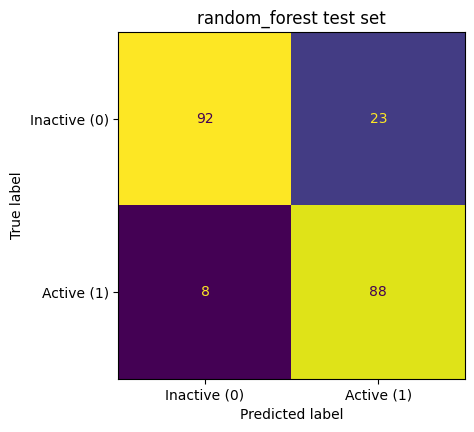

In [11]:
selected_baseline_model = build_model(selected_baseline_family, selected_hyperparameters)
selected_baseline_model.fit(X_train, y_train)

selected_validation_probabilities = predict_probabilities(selected_baseline_model, X_validation)
selected_test_probabilities = predict_probabilities(selected_baseline_model, X_test)

selected_validation_metrics = compute_binary_classification_metrics(
    y_validation,
    selected_validation_probabilities,
)
selected_test_metrics = compute_binary_classification_metrics(
    y_test,
    selected_test_probabilities,
)
selected_test_predictions = (selected_test_probabilities >= 0.5).astype(np.int64)
selected_test_confusion_matrix = confusion_matrix(
    y_test,
    selected_test_predictions,
    labels=[0, 1],
)

selected_baseline_summary = pd.DataFrame(
    [
        {
            "selected_model_family": selected_baseline_family,
            **selected_hyperparameters,
            "validation_accuracy": selected_validation_metrics["accuracy"],
            "validation_precision": selected_validation_metrics["precision"],
            "validation_recall": selected_validation_metrics["recall"],
            "validation_f1": selected_validation_metrics["f1"],
            "validation_roc_auc": selected_validation_metrics["roc_auc"],
            "validation_log_loss": selected_validation_metrics["log_loss"],
            "test_accuracy": selected_test_metrics["accuracy"],
            "test_precision": selected_test_metrics["precision"],
            "test_recall": selected_test_metrics["recall"],
            "test_f1": selected_test_metrics["f1"],
            "test_roc_auc": selected_test_metrics["roc_auc"],
            "test_log_loss": selected_test_metrics["log_loss"],
        }
    ]
)

test_confusion_summary = pd.DataFrame(
    [
        {
            "selected_model_family": selected_baseline_family,
            "tn": int(selected_test_confusion_matrix[0, 0]),
            "fp": int(selected_test_confusion_matrix[0, 1]),
            "fn": int(selected_test_confusion_matrix[1, 0]),
            "tp": int(selected_test_confusion_matrix[1, 1]),
        }
    ]
)

display(selected_baseline_summary)
display(test_confusion_summary)

confusion_matrix_figure, confusion_matrix_axis = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=selected_test_confusion_matrix,
    display_labels=list(CLASS_LABELS),
).plot(ax=confusion_matrix_axis, colorbar=False, values_format="d")
confusion_matrix_axis.set_title(f"{selected_baseline_family} test set")
display(confusion_matrix_figure)
plt.close(confusion_matrix_figure)

In [12]:
run_timestamp = datetime.now().isoformat(timespec="seconds")

validation_trials_path = RUN_DIR / "validation_trials.csv"
family_winners_path = RUN_DIR / "family_winners.csv"
summary_path = RUN_DIR / "selected_baseline_summary.csv"
confusion_summary_path = RUN_DIR / "test_confusion_summary.csv"
json_path = RUN_DIR / "summary.json"
confusion_matrix_path = PLOTS_DIR / "selected_baseline_test_confusion_matrix.png"

validation_trials_df.to_csv(validation_trials_path, index=False)
family_winners_df.to_csv(family_winners_path, index=False)
selected_baseline_summary.to_csv(summary_path, index=False)
test_confusion_summary.to_csv(confusion_summary_path, index=False)

confusion_matrix_figure, confusion_matrix_axis = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=selected_test_confusion_matrix,
    display_labels=list(CLASS_LABELS),
).plot(ax=confusion_matrix_axis, colorbar=False, values_format="d")
confusion_matrix_axis.set_title(f"{selected_baseline_family} test set")
confusion_matrix_figure.tight_layout()
confusion_matrix_figure.savefig(
    confusion_matrix_path,
    dpi=200,
    bbox_inches="tight",
)
plt.close(confusion_matrix_figure)

payload = {
    "run_directory": RUN_DIR.relative_to(PROJECT_ROOT).as_posix(),
    "run_timestamp": run_timestamp,
    "data_directory": DATA_DIR.relative_to(PROJECT_ROOT).as_posix(),
    "selection_protocol": {
        "train_split_only_for_fitting": True,
        "validation_primary_metric": "f1",
        "validation_secondary_metric": "roc_auc",
        "decision_threshold": 0.5,
        "test_set_touched_after_freeze_only": True,
    },
    "model_grid_sizes": {
        model_family: len(configs)
        for model_family, configs in MODEL_GRIDS.items()
    },
    "selected_model_family": selected_baseline_family,
    "selected_hyperparameters": selected_hyperparameters,
    "artifacts": {
        "validation_trials_file": validation_trials_path.relative_to(PROJECT_ROOT).as_posix(),
        "family_winners_file": family_winners_path.relative_to(PROJECT_ROOT).as_posix(),
        "selected_baseline_summary_file": summary_path.relative_to(PROJECT_ROOT).as_posix(),
        "test_confusion_summary_file": confusion_summary_path.relative_to(PROJECT_ROOT).as_posix(),
        "test_confusion_matrix_file": confusion_matrix_path.relative_to(PROJECT_ROOT).as_posix(),
    },
    "family_winners": family_winners_df.to_dict(orient="records"),
    "selected_baseline_summary": selected_baseline_summary.to_dict(orient="records"),
}

with json_path.open("w", encoding="utf-8") as file:
    json.dump(payload, file, indent=2)

display(selected_baseline_summary)
display(test_confusion_summary)
print(f"Saved run directory: {RUN_DIR}")
print(f"Saved validation trials CSV: {validation_trials_path}")
print(f"Saved family winners CSV: {family_winners_path}")
print(f"Saved selected-baseline summary CSV: {summary_path}")
print(f"Saved test confusion summary CSV: {confusion_summary_path}")
print(f"Saved summary JSON: {json_path}")
print(f"Saved confusion matrix figure: {confusion_matrix_path}")

,selected_model_family,class_weight,n_estimators,max_depth,min_samples_leaf,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_log_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_log_loss
0,random_forest,balanced,200.0,10.0,1.0,0.881517,0.858586,0.885417,0.871795,0.947101,0.317753,0.853081,0.792793,0.916667,0.850242,0.93981,0.337566


,selected_model_family,tn,fp,fn,tp
0,random_forest,92,23,8,88


Saved run directory: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\classical_ml_baseline\experiment_001
Saved validation trials CSV: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\classical_ml_baseline\experiment_001\validation_trials.csv
Saved family winners CSV: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\classical_ml_baseline\experiment_001\family_winners.csv
Saved selected-baseline summary CSV: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\classical_ml_baseline\experiment_001\selected_baseline_summary.csv
Saved test confusion summary CSV: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\classical_ml_baseline\experiment_001\test_confusion_summary.csv
Saved summary JSON: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\classical_ml_baseline\experiment_001\summary.json
Saved confusion matrix figure: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\classical_ml_baseline\experiment_001\plots\selected_baseline_test_confusion_matrix.png
